In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

#Funciones a usar

def sol_trsupcol(A, b):
    n = len(b)
    x = b.copy()

    for idx in reversed(range(n)):
        if b[idx] != 0:
            j = idx
            break

    for i in reversed(range(j + 1)):
        x[i] = x[i] / A[i, i]
        x[:i] = x[:i] - A[:i, i] * x[i]

    return x


def givens(x1,x2):
    c = 1.
    s = 0.
    ax1 = abs(x1)
    ax2 = abs(x2)
    if ax1 + ax2 > 0:
        if ax2 > ax1:
            tau = -x1/x2
            s = -np.sign(x2)/np.sqrt(1 + tau**2)
            c = tau*s
        else:
            tau = -x2/x1
            c = np.sign(x1)/np.sqrt(1 + tau**2)
            s = tau*c
    return c, s


def qrgivensp(A):
    m, n = A.shape
    Q = np.eye(m)
    P = np.eye(n)
    R = A.copy()
    # Forma rápida de calcular la norma de todas las columnas de A
    c_norm = np.linalg.norm(A, axis=0) ** 2
    p = min(m - 1, n)

    for j in range(p):
        # Pivoteo por derecha, cambiando columnas en vez de filas
        ind_pivot = j + np.argmax(c_norm[j:])
        if ind_pivot != j:
            R[:, [ind_pivot, j]] = R[:, [j, ind_pivot]]
            P[:, [ind_pivot, j]] = P[:, [j, ind_pivot]]
            c_norm[[ind_pivot, j]] = c_norm[[j, ind_pivot]]
        # Givens común y corriente
        for i in range(j+1, m):
            if R[i, j] != 0:
                #I = [j, i], J = j:
                c, s = givens(R[j, j], R[i, j])
                G = np.array([[c, -s], [s, c]])

                R[[j, i], j:] = G @ R[[j, i], j:]
                Q[:, [j, i]] = Q[:, [j, i]] @ G.T
        # Actualización de c_norm SOLO UNA VEZ DESPUES DE ACTUALIZAR FILAS
        c_norm[j:] = c_norm[j:] - R[j, j:] * R[j, j:]

    if m <= n and R[m - 1, m - 1] < 0:
        # J = m:
        R[m - 1, m - 1:] = -R[m - 1, m - 1:]
        Q[:, m - 1] = -Q[:, m - 1]

    return Q, R, P

######################################################

#EJERCICIO 7

def sol_cuadmin(A, b):
    m, n = A.shape
    Q, R, P = qrgivensp(A)

    y = np.zeros(n)
    q = Q.T @ b
    r = np.diag(R)
    p = min(m,n)
    busqueda_ceros = np.where(r == 0)[0] #np.where nos devuelve el indice o la posicion del elemnto que estamos buscando
    if len(busqueda_ceros) != 0:
        p = busqueda_ceros[0] #Aqui es mejor que nos devuelva el primer elemento que es cero en la diagonal de R

    y[:p] = sol_trsupcol(R[:p, :p], q[:p])

    x = P@y

    return  x, np.linalg.norm(q[p:])


#Ejercicio 11

In [2]:
datos = np.loadtxt('dryer2.dat.txt')

FileNotFoundError: dryer2.dat.txt not found.

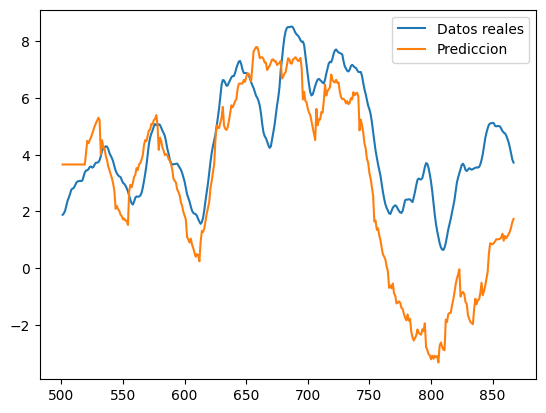

In [ ]:
t = datos[: , 0] # Columna 1 de datos

u_t = datos[:, 1] # Columna 2 de datos

y_t = datos[: , 4] # Columna 5 de datos

def prediccion(N, tau):
    time = datos[: , 0] # Tiempo total
    u_t = datos[:, 1] # Datos u(t)
    y_t = datos[: , 4] # Datos y(t)
    tiempo_final = len(time)
    b = y_t[tau:N+1] # Definimos el vector de salida b como = [y(tau) y(tau+1)... y(N)].
    A = np.zeros((N-tau+1, tau+1)) #Armamos la matriz de coeficientes
    for t in range(tau, N-tau+2):  #Nos movemos de tau hasta N-tau+1
            A[t-tau,:] = u_t[t-tau:t+1] # Pisamos sobre cada fila de la matriz A por el vector [u(t-tau) u(t-tau+1)... u(t)]
    h_tau = sol_cuadmin(A, b)[0] # Encontramos h usando sol_cuadmin

    # A partir de aqui vamos a predecir y(t) usando h_tau con t mayor o igual que N+1
    ent = np.zeros((tiempo_final-N, tau+1)) #Armamos una matriz de coeficiente con el tiempo que queda en datos
    for j in range(tiempo_final-N):
        ent[j, :] = u_t[N+j-tau:N+1+j] # Aqui pisamos por los coeficientes [u(t-tau) u(t-tau+1)... u(t)] para t mayor o igual a N+1

    predic = ent @ h_tau # Hacemos el producto y obtenemos la prediccion [y(N+1) y(N+2)... y(tiempo_final)]

    plt.plot(time[N:], y_t[N:], label = 'Datos reales') # Datos reales de y(t)
    plt.plot(time[N:], predic, label = 'Prediccion') # Predicciones de y(t)
    plt.legend()
    plt.show()

#Probamos con N = 500 y tau = 100
prediccion(500, 100)